In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
import missingno as msno

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

In [2]:
file_path = '../data/raw/Give Me Some Credit/cs-training.csv'

try:
    df = pd.read_csv(file_path, index_col=0)
    print(f"Data Shape: {df.shape}")
    display(df.head())
    display(df.info())
except FileNotFoundError:
    print("Error: File not found. Verify the exact path and filename.")

Data Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

None

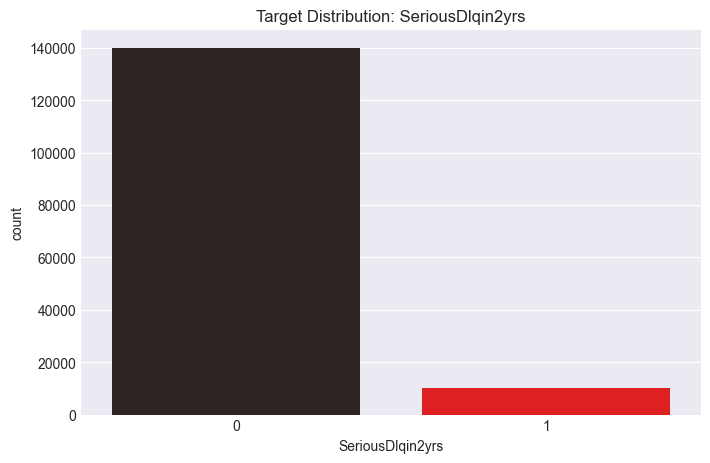

--- Target Class Proportions (%) ---
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


In [3]:
target_col = 'SeriousDlqin2yrs'

if target_col in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    plt_sns.countplot(data=df, x=target_col, ax=ax, hue=target_col, palette='dark:red', legend=False)
    plt.title('Target Distribution: SeriousDlqin2yrs')
    plt.savefig("target_distribution", dpi=300, bbox_inches="tight")
    plt.show()
    
    print("--- Target Class Proportions (%) ---")
    print(df[target_col].value_counts(normalize=True) * 100)
else:
    print(f"Error: Target column '{target_col}' not found.")

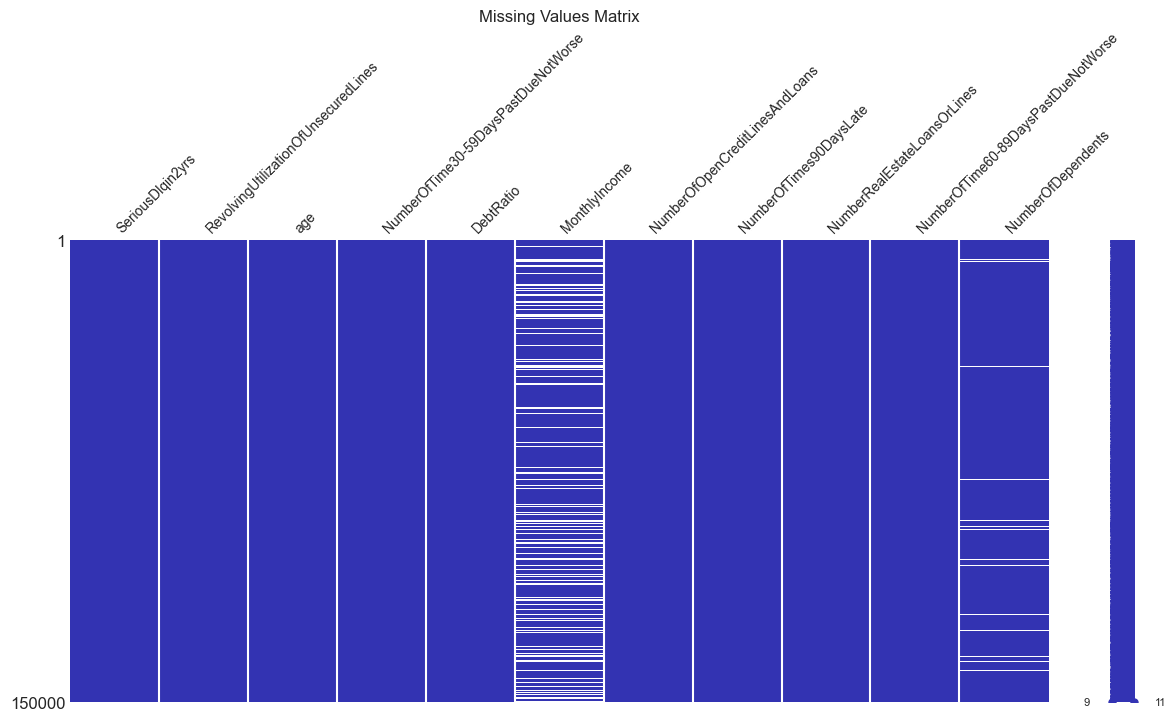

In [4]:
msno.matrix(df, figsize=(14, 6), fontsize=10, color=(0.2, 0.2, 0.7))
plt.title('Missing Values Matrix')
plt.savefig("missing_values_matrix", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_19180\982031194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plt_sns.boxplot(x=df[target_col], y=df['DebtRatio'], ax=axes[0], palette='Set1')
C:\Users\user\AppData\Local\Temp\ipykernel_19180\982031194.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plt_sns.boxplot(x=df[target_col], y=df['MonthlyIncome'], ax=axes[1], palette='Set1')


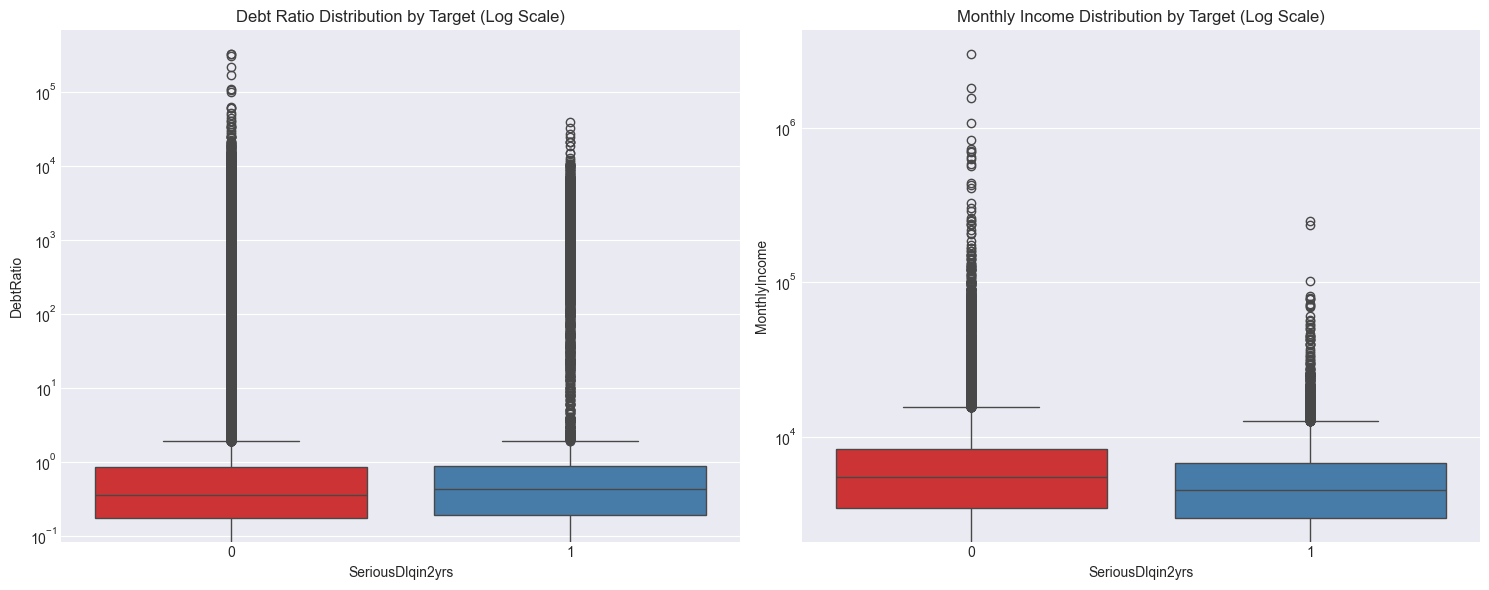

--- Extreme Anomaly Check ---
Max DebtRatio: 329664.0
Max MonthlyIncome: 3008750.0
Min Age: 0
Max Age: 109


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plt_sns.boxplot(x=df[target_col], y=df['DebtRatio'], ax=axes[0], palette='Set1')
axes[0].set_title('Debt Ratio Distribution by Target (Log Scale)')
axes[0].set_yscale('log')

plt_sns.boxplot(x=df[target_col], y=df['MonthlyIncome'], ax=axes[1], palette='Set1')
axes[1].set_title('Monthly Income Distribution by Target (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("monthly_income_distribution", dpi=300, bbox_inches="tight")
plt.show()

print("--- Extreme Anomaly Check ---")
print(f"Max DebtRatio: {df['DebtRatio'].max()}")
print(f"Max MonthlyIncome: {df['MonthlyIncome'].max()}")
print(f"Min Age: {df['age'].min()}")
print(f"Max Age: {df['age'].max()}")

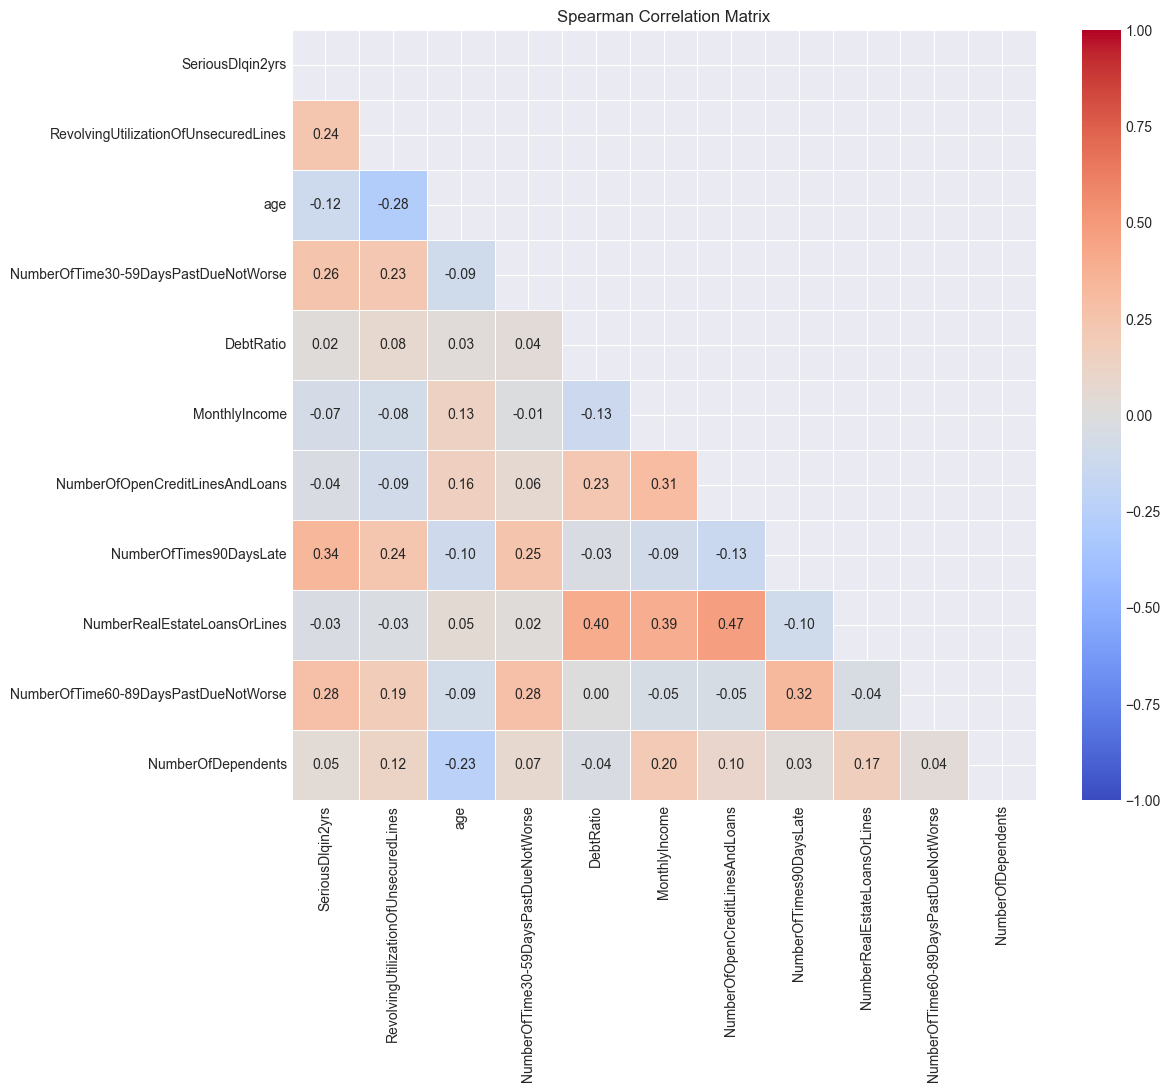

In [6]:
plt.figure(figsize=(12, 10))
corr_matrix = df.corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt_sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title('Spearman Correlation Matrix')
plt.savefig("spearman_corr_matrix", dpi=300, bbox_inches="tight")
plt.show()

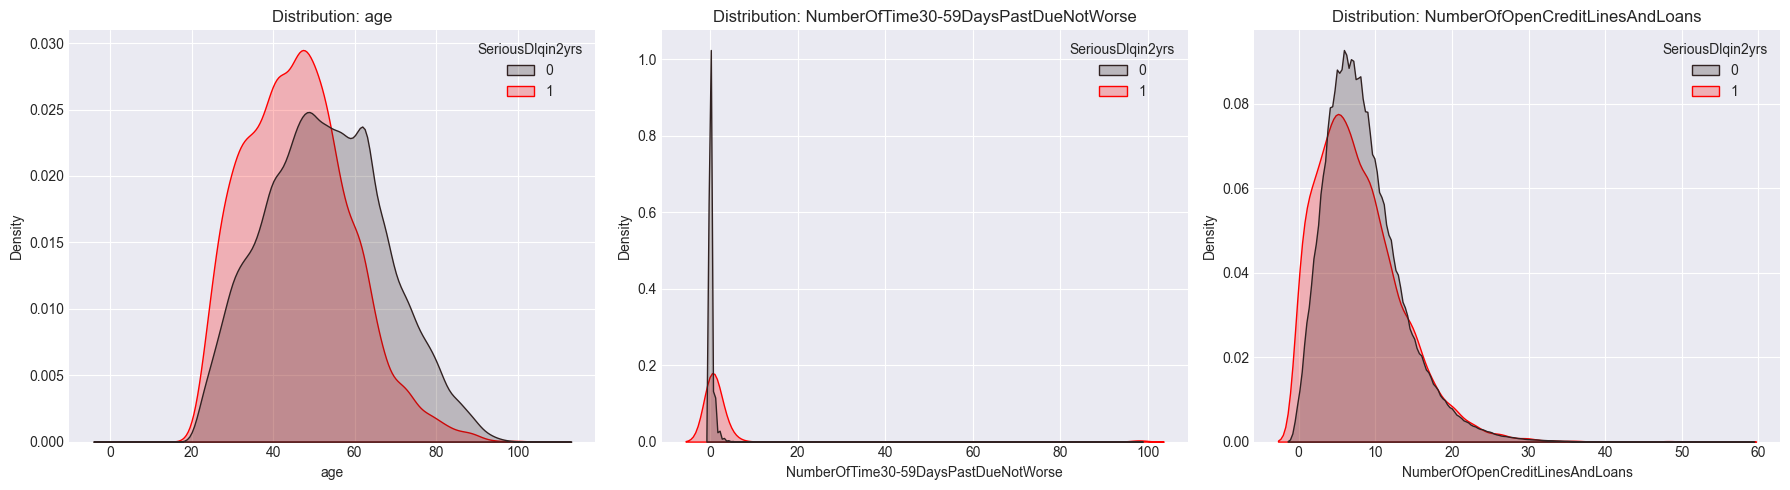

In [7]:
features_to_plot = ['age', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfOpenCreditLinesAndLoans']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(features_to_plot):
    plt_sns.kdeplot(data=df, x=feature, hue=target_col, ax=axes[i], common_norm=False, fill=True, palette='dark:red')
    axes[i].set_title(f'Distribution: {feature}')
    
plt.tight_layout()
plt.savefig("distribution", dpi=300, bbox_inches="tight")
plt.show()